In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
base_dir = "/content/drive/MyDrive/helmet_detection_project"
os.makedirs(base_dir, exist_ok=True)
print("Project folder:", base_dir)

Project folder: /content/drive/MyDrive/helmet_detection_project


In [ ]:
base_dir = "/content/drive/MyDrive/helmet_detection_project"
data_yaml = base_dir + "/dataset/data.yaml"
os.environ["YOLO_DIR"] = base_dir + "/runs"


In [ ]:
!pip install -q ultralytics==8.*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.5 MB/s eta 0:00:00


In [ ]:
import os, glob

# change this to wherever your zip was extracted
ann_dir = "/content/drive/MyDrive/Helemt detection dataset/annotations"

# List the first 10 annotation files with extensions
ann_files = glob.glob(os.path.join(ann_dir, "*"))
print("Total annotation files:", len(ann_files))
print("First few files:", ann_files[:10])

# Check file extensions
exts = set([os.path.splitext(f)[1].lower() for f in ann_files])
print("Unique annotation file types found:", exts)

Total annotation files: 764
First few files: ['/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets155.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets111.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets157.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets110.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets145.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets123.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets147.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets15.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets151.xml', '/content/drive/MyDrive/Helemt detection dataset/annotations/BikesHelmets146.xml']
Unique annotation file types found: {'.xml'}


In [ ]:
# Colab cell: VOC (.xml) -> YOLO (.txt) converter
import os, glob, xml.etree.ElementTree as ET
from collections import OrderedDict

# === EDIT THESE PATHS if different ===
base = "/content/drive/MyDrive/Helemt detection dataset"  # change to your dataset root
xml_dir = os.path.join(base, "/content/drive/MyDrive/Helemt detection dataset/annotations")
img_dir = os.path.join(base, "/content/drive/MyDrive/Helemt detection dataset/images")      # folder with your .png images
out_label_dir = os.path.join(base, "labels_yolo")  # where YOLO .txts will be written
os.makedirs(out_label_dir, exist_ok=True)

# helper to find image file given image base name (without extension)
def find_image_file(base_dir, base_name, exts=('.png','.jpg','.jpeg','.bmp')):
    for e in exts:
        p = os.path.join(base_dir, base_name + e)
        if os.path.exists(p):
            return p
    return None

# gather xmls
xml_files = sorted(glob.glob(os.path.join(xml_dir, "*.xml")))
print(f"Found {len(xml_files)} XML files in: {xml_dir}")

# first pass: collect unique class names
classes = OrderedDict()
for xf in xml_files:
    try:
        tree = ET.parse(xf)
        root = tree.getroot()
        for obj in root.findall('object'):
            name = obj.find('name').text.strip()
            if name not in classes:
                classes[name] = len(classes)  # assign incremental id
    except Exception as e:
        print("Error parsing", xf, e)

print("Detected classes and assigned ids:")
for cname, cid in classes.items():
    print(f"  {cid}: {cname}")
if not classes:
    print("WARNING: No object classes found in XMLs. Check XML format.")

# Save class list to file for later use (data.yaml)
classes_txt = os.path.join(base, "classes.txt")
with open(classes_txt, "w") as f:
    for cname in classes:
        f.write(cname + "\n")
print("Wrote classes file to:", classes_txt)

# conversion function (VOC bndbox -> normalized x_center y_center w h)
def convert_bbox(size, box):
    # size: (width, height) ; box: (xmin, ymin, xmax, ymax)
    w_img, h_img = size
    xmin, ymin, xmax, ymax = box
    x_center = (xmin + xmax) / 2.0
    y_center = (ymin + ymax) / 2.0
    box_w = xmax - xmin
    box_h = ymax - ymin
    # normalize
    x = x_center / w_img
    y = y_center / h_img
    bw = box_w / w_img
    bh = box_h / h_img
    return x, y, bw, bh

# Convert XML -> TXT
missing_images = []
converted = 0
empty_annotations = 0
for xf in xml_files:
    try:
        tree = ET.parse(xf)
        root = tree.getroot()
        # image filename in xml (sometimes includes extension)
        fname_node = root.find('filename')
        if fname_node is not None:
            img_name = fname_node.text.strip()
            base_name = os.path.splitext(img_name)[0]
        else:
            # fallback to xml name
            base_name = os.path.splitext(os.path.basename(xf))[0]

        # try to find the image file in img_dir
        img_path = find_image_file(img_dir, base_name)
        if img_path is None:
            # maybe images are in a nested folder or have different naming; try searching full images dir
            # search for any file that starts with base_name
            candidates = glob.glob(os.path.join(img_dir, "**", base_name + ".*"), recursive=True)
            img_path = candidates[0] if candidates else None

        if img_path is None:
            missing_images.append((xf, base_name))
            continue

        # get image size from xml (preferred) else fallback to reading image via PIL
        size_node = root.find('size')
        if size_node is not None:
            img_w = int(size_node.find('width').text)
            img_h = int(size_node.find('height').text)
        else:
            # lazy image size reading (requires PIL)
            try:
                from PIL import Image
                with Image.open(img_path) as im:
                    img_w, img_h = im.size
            except Exception as e:
                print("Cannot read image size for", img_path, "error:", e)
                missing_images.append((xf, base_name))
                continue

        lines = []
        for obj in root.findall('object'):
            cname = obj.find('name').text.strip()
            if cname not in classes:
                # unseen (shouldn't happen)
                continue
            cid = classes[cname]
            bnd = obj.find('bndbox')
            xmin = float(bnd.find('xmin').text)
            ymin = float(bnd.find('ymin').text)
            xmax = float(bnd.find('xmax').text)
            ymax = float(bnd.find('ymax').text)
            # handle degenerate boxes
            if xmax <= xmin or ymax <= ymin:
                # skip degenerate
                continue
            x,y,w,h = convert_bbox((img_w, img_h), (xmin, ymin, xmax, ymax))
            # clamp values to (0,1)
            x = min(max(x, 0.0), 1.0)
            y = min(max(y, 0.0), 1.0)
            w = min(max(w, 0.0), 1.0)
            h = min(max(h, 0.0), 1.0)
            lines.append(f"{cid} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

        out_txt = os.path.join(out_label_dir, base_name + ".txt")
        if lines:
            with open(out_txt, "w") as f:
                f.write("\n".join(lines))
            converted += 1
        else:
            # write empty file or skip — we'll note it
            empty_annotations += 1
            # create an empty file so YOLO can still pair (optional)
            open(out_txt, "w").close()
    except Exception as e:
        print("Error converting", xf, ":", e)

print("Conversion finished.")
print("Converted files with >=1 object:", converted)
print("XMLs with zero objects (empty annotations):", empty_annotations)
print("XMLs missing matching image:", len(missing_images))
if missing_images:
    print("Sample missing:", missing_images[:10])

print("YOLO labels written to:", out_label_dir)
print("NOTE: If your training expects labels next to images, you can move/copy these txts next to your images or update dataset code to point to labels_yolo.")


Found 764 XML files in: /content/drive/MyDrive/Helemt detection dataset/annotations
Detected classes and assigned ids:
  0: With Helmet
  1: Without Helmet
Wrote classes file to: /content/drive/MyDrive/Helemt detection dataset/classes.txt
Conversion finished.
Converted files with >=1 object: 761
XMLs with zero objects (empty annotations): 3
XMLs missing matching image: 0
YOLO labels written to: /content/drive/MyDrive/Helemt detection dataset/labels_yolo
NOTE: If your training expects labels next to images, you can move/copy these txts next to your images or update dataset code to point to labels_yolo.


In [ ]:
# EDIT base path if needed
import os, glob, shutil, random
random.seed(42)

base = "/content/drive/MyDrive/Helemt detection dataset (1)"
imgs_dir = os.path.join(base, "/content/drive/MyDrive/Helemt detection dataset/images")         # your png images
labels_src = os.path.join(base,"/content/drive/MyDrive/Helemt detection dataset/labels_yolo") # converted labels location
work = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo"                   # working dataset folder in Colab
os.makedirs(work, exist_ok=True)

# create structure
for d in ["images/train","images/val","labels/train","labels/val"]:
    os.makedirs(os.path.join(work, d), exist_ok=True)

# gather images (png primarily)
img_paths = glob.glob(os.path.join(imgs_dir, "*.png")) + glob.glob(os.path.join(imgs_dir, "*.jpg")) + glob.glob(os.path.join(imgs_dir, "*.jpeg"))
print("Total images found:", len(img_paths))
random.shuffle(img_paths)
split_idx = int(0.8 * len(img_paths))
train_imgs = img_paths[:split_idx]
val_imgs = img_paths[split_idx:]

def copy_set(img_list, dest_img_dir, dest_label_dir):
    copied = 0
    missing_label = 0
    for p in img_list:
        fname = os.path.basename(p)
        base_name = os.path.splitext(fname)[0]
        dst_img = os.path.join(dest_img_dir, fname)
        shutil.copy(p, dst_img)
        # label paths to check
        label_src_candidates = [
            os.path.join(labels_src, base_name + ".txt"),         # converted labels
            os.path.join(os.path.dirname(p), base_name + ".txt")  # label next to image (if any)
        ]
        found = False
        for lab in label_src_candidates:
            if os.path.exists(lab):
                shutil.copy(lab, os.path.join(dest_label_dir, base_name + ".txt"))
                found = True
                break
        if not found:
            # create empty label file (YOLO requires pair, but empty txt allowed for negative images)
            open(os.path.join(dest_label_dir, base_name + ".txt"), "w").close()
            missing_label += 1
        copied += 1
    return copied, missing_label

t_copied, t_missing = copy_set(train_imgs, os.path.join(work,"images/train"), os.path.join(work,"labels/train"))
v_copied, v_missing = copy_set(val_imgs,   os.path.join(work,"images/val"),   os.path.join(work,"labels/val"))

print(f"Train images: {t_copied} (missing labels: {t_missing})")
print(f"Val images:   {v_copied} (missing labels: {v_missing})")
print("Dataset created at:", work)


Total images found: 764
Train images: 611 (missing labels: 0)
Val images:   153 (missing labels: 0)
Dataset created at: /content/drive/MyDrive/helmet_detection_project/helmet-yolo


In [ ]:
# build data.yaml
work = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo" # same as above
classes_file = "/content/drive/MyDrive/Helemt detection dataset/classes.txt"
with open(classes_file) as f:
    names = [x.strip() for x in f.readlines() if x.strip()]
print("Classes:", names)

data_yaml = {
    "train": os.path.join(work, "images/train"),
    "val":   os.path.join(work, "images/val"),
    "nc": len(names),
    "names": names
}

import yaml
out_yaml_path = os.path.join(work, "data.yaml")
with open(out_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)
print("Wrote:", out_yaml_path)
print("Contents:")
print(open(out_yaml_path).read())


Classes: ['With Helmet', 'Without Helmet']
Wrote: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/data.yaml
Contents:
train: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/train
val: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val
nc: 2
names:
- With Helmet
- Without Helmet



In [ ]:
from ultralytics import YOLO
import os

# ✅ Path setup
work = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo"
data_yaml = os.path.join(work, "data.yaml")  # ✅ fixed join (no extra '/content/...')

# ✅ Load YOLOv8 model (nano version — fast and lightweight)
model = YOLO("yolov8n.pt")

# ✅ Start training
model.train(
    data=data_yaml,          # path to your dataset config file
    epochs=30,               # number of training epochs
    imgsz=640,               # image size
    batch=16,                # adjust to 8 or 4 if memory error
    name="helmet_yolov8n",   # run name (saves under /runs/train/helmet_yolov8n)
    project="/content/drive/MyDrive/helmet_detection_project/runs"  # ✅ saves directly to Drive
)


Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/helmet_detection_project/helmet-yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=helmet_yolov8n2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dfd6e1618e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


image 1/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png: 480x640 1 With Helmet, 6.6ms
image 2/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png: 384x640 1 With Helmet, 96.4ms
image 3/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets113.png: 480x640 1 With Helmet, 1 Without Helmet, 7.2ms
image 4/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets115.png: 416x640 2 With Helmets, 4 Without Helmets, 40.4ms
image 5/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets116.png: 448x640 5 With Helmets, 3 Without Helmets, 40.3ms
image 6/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets124.png: 480x640 7 With Helmets, 7.2ms
image 7/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets130.png: 448x640 1 Without Helmet, 6.8ms
image

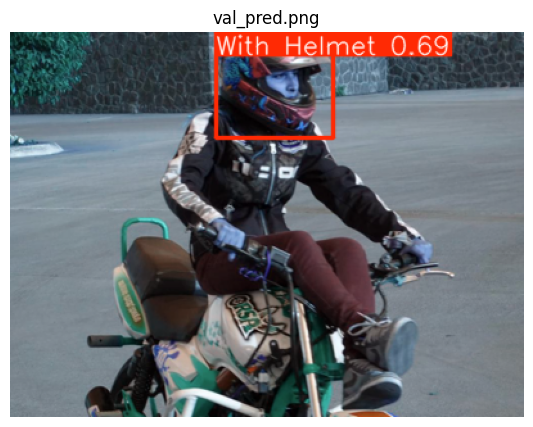

Saved prediction images (sample):
 - /content/val_pred.png

If you see many false positives or missed 'Without Helmet' cases, paste 1–3 example filenames here and I'll tell you exactly what to do next.


In [ ]:
# Visualize predictions on 6 validation images (single step)

from ultralytics import YOLO
import glob, IPython.display as disp
from PIL import Image
import matplotlib.pyplot as plt
import os

# path to best weights (adjust only if different)
WEIGHT = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
assert os.path.exists(WEIGHT), f"Weight not found: {WEIGHT}"

# load model
model = YOLO(WEIGHT)

# pick first 6 val images
val_images = sorted(glob.glob("/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val*"))
if len(val_images) == 0:
    raise SystemExit("No val images found at /content/helmet-yolo/images/val")
samples = val_images[:6]

# run predictions and save images
out_paths = []
for p in samples:
    res = model.predict(p, imgsz=640, save=True)  # saves to runs/detect/predict by default
    # res[0].save_dir contains folder; prediction image files are placed there
    out_dir = str(res[0].save_dir)
    # find the saved image(s) for this input (saved name ends with same base)
    base = os.path.splitext(os.path.basename(p))[0]
    candidates = glob.glob(os.path.join(out_dir, base + "*.jpg")) + glob.glob(os.path.join(out_dir, base + "*.png"))
    if candidates:
        out_paths.append(candidates[0])
    else:
        # fallback: use plotted image from results
        out_img = res[0].plot()
        tmp = f"/content/{base}_pred.png"
        Image.fromarray(out_img).save(tmp)
        out_paths.append(tmp)

# Display the prediction images inline (grid)
n = len(out_paths)
cols = 3
rows = (n + cols - 1)//cols
plt.figure(figsize=(16, 6*rows))
for i, p in enumerate(out_paths):
    img = Image.open(p)
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(p))
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Saved prediction images (sample):")
for p in out_paths:
    print(" -", p)
print("\nIf you see many false positives or missed 'Without Helmet' cases, paste 1–3 example filenames here and I'll tell you exactly what to do next.")



image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png: 480x640 1 With Helmet, 8.7ms
Speed: 2.8ms preprocess, 8.7ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/predict_helmet

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png: 384x640 1 With Helmet, 21.7ms
Speed: 5.0ms preprocess, 21.7ms inference, 4.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/predict_helmet

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets113.png: 480x640 1 With Helmet, 1 Without Helmet, 8.7ms
Speed: 2.9ms preprocess, 8.7ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/predict_helmet

image 1/1 /content/dr

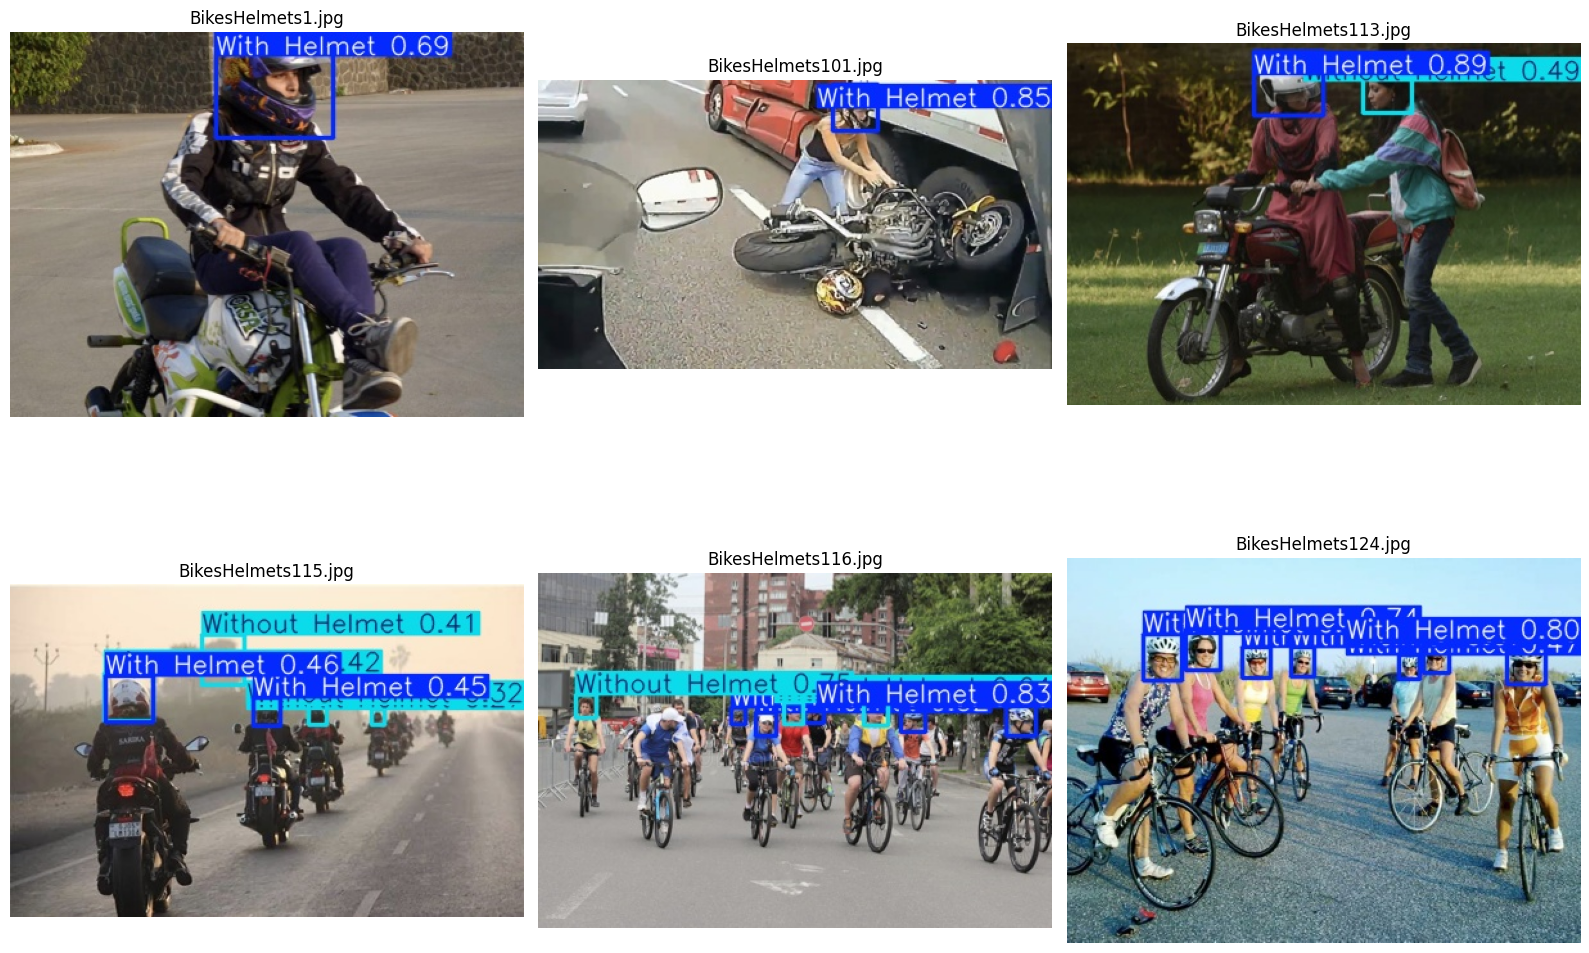

/content/drive/MyDrive/helmet_detection_project/runs/detect/predict_helmet/


In [ ]:
from ultralytics import YOLO
import glob, os
from PIL import Image
import matplotlib.pyplot as plt

# ✅ Correct model path
WEIGHT = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
assert os.path.exists(WEIGHT), f"Weight not found: {WEIGHT}"

# ✅ Load model
model = YOLO(WEIGHT)

# ✅ Drive folder to save predictions
save_dir = "/content/drive/MyDrive/helmet_detection_project/runs/detect/predict_helmet"
os.makedirs(save_dir, exist_ok=True)

# ✅ Pick validation images
val_images = sorted(glob.glob("/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/*"))
if len(val_images) == 0:
    raise SystemExit("No validation images found at the given path.")
samples = val_images[:6]

# ✅ Run inference and save results to Drive
out_paths = []
for p in samples:
    res = model.predict(
        source=p,
        imgsz=640,
        save=True,
        project="/content/drive/MyDrive/helmet_detection_project/runs/detect",  # 🔥 saves in Drive
        name="predict_helmet",  # folder name
        exist_ok=True           # overwrite safely if folder exists
    )
    out_dir = str(res[0].save_dir)
    base = os.path.splitext(os.path.basename(p))[0]
    candidates = glob.glob(os.path.join(out_dir, base + "*.jpg")) + glob.glob(os.path.join(out_dir, base + "*.png"))
    if candidates:
        out_paths.append(candidates[0])

# ✅ Display predictions inline
n = len(out_paths)
cols = 3
rows = (n + cols - 1)//cols
plt.figure(figsize=(16, 6*rows))
for i, p in enumerate(out_paths):
    img = Image.open(p)
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(p))
    plt.axis('off')
plt.tight_layout()
plt.show()

print("/content/drive/MyDrive/helmet_detection_project/runs/detect/predict_helmet/")


In [ ]:
from ultralytics import YOLO
import glob, os
from PIL import Image

WEIGHT = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
val_images = sorted(glob.glob("/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/*"))
save_project = "/content/drive/MyDrive/helmet_detection_project/runs/detect"
save_name = "predict_all_val_loop"

model = YOLO(WEIGHT)
os.makedirs(os.path.join(save_project, save_name), exist_ok=True)

out_paths = []
for p in val_images:
    res = model.predict(source=p, imgsz=640, conf=0.25, save=True,
                        project=save_project, name=save_name, exist_ok=True)
    out_dir = str(res[0].save_dir)
    base = os.path.splitext(os.path.basename(p))[0]
    candidates = glob.glob(os.path.join(out_dir, base + "*.jpg")) + glob.glob(os.path.join(out_dir, base + "*.png"))
    if candidates:
        out_paths.append(candidates[0])

print(f"Processed {len(out_paths)} images. Results in {os.path.join(save_project, save_name)}")



image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png: 480x640 1 With Helmet, 6.5ms
Speed: 1.7ms preprocess, 6.5ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/predict_all_val_loop

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png: 384x640 1 With Helmet, 25.8ms
Speed: 2.2ms preprocess, 25.8ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/predict_all_val_loop

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets113.png: 480x640 1 With Helmet, 1 Without Helmet, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/predict_all_val_loop

ima

In [ ]:
# Step: Find validation images with lowest average confidence (fixed version)

from ultralytics import YOLO
import pandas as pd
import numpy as np
import torch
import glob, os

MODEL_PATH ="/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"  # change if needed
VAL_PATH = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val"

# 1. Run predictions on all validation images (no saving images)
model = YOLO(MODEL_PATH)
results = model.predict(VAL_PATH, imgsz=640, save=False, conf=0.25, stream=True)

# 2. Collect per-image average confidence
conf_data = []
for r in results:
    img_name = os.path.basename(r.path)
    if r.boxes.conf is not None and len(r.boxes.conf) > 0:
        # convert tensor to numpy safely
        avg_conf = float(torch.mean(r.boxes.conf).cpu().numpy())
    else:
        avg_conf = 0.0
    conf_data.append((img_name, avg_conf))

df = pd.DataFrame(conf_data, columns=["image", "avg_confidence"])
df = df.sort_values(by="avg_confidence").reset_index(drop=True)

# 3. Show 10 lowest-confidence predictions
print("10 images with lowest average confidence:")
print(df.head(10))

# 4. Save list to CSV
df.to_csv("/content/drive/MyDrive/helmet_detection_project/low_conf_val_images.csv", index=False)
print("\nSaved full list to /content/low_conf_val_images.csv")



image 1/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png: 480x640 1 With Helmet, 6.5ms
image 2/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png: 384x640 1 With Helmet, 17.8ms
image 3/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets113.png: 480x640 1 With Helmet, 1 Without Helmet, 7.3ms
image 4/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets115.png: 416x640 2 With Helmets, 4 Without Helmets, 6.6ms
image 5/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets116.png: 448x640 5 With Helmets, 3 Without Helmets, 6.6ms
image 6/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets124.png: 480x640 7 With Helmets, 6.6ms
image 7/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets130.png: 448x640 1 Without Helmet, 6.5ms
image 8


image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets738.png: 640x448 (no detections), 6.7ms
Speed: 1.6ms preprocess, 6.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets569.png: 448x640 1 With Helmet, 7.4ms
Speed: 2.4ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets603.png: 448x640 1 With Helmet, 6.0ms
Speed: 1.5ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets643.png: 448x640 6 Without Helmets, 5.8ms
Speed: 1.5ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/

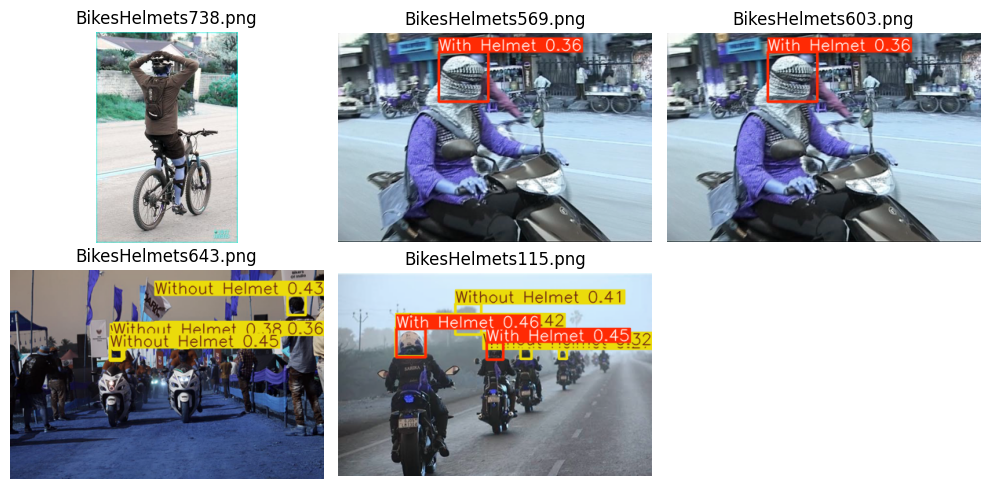

In [ ]:
# Step: visually inspect the weakest 5 images

from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os

MODEL_PATH = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
VAL_PATH = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val"
model = YOLO(MODEL_PATH)

weak_imgs = [
    "BikesHelmets738.png",
    "BikesHelmets569.png",
    "BikesHelmets603.png",
    "BikesHelmets643.png",
    "BikesHelmets115.png"
]

plt.figure(figsize=(10, 5))
for i, name in enumerate(weak_imgs, 1):
    img_path = os.path.join(VAL_PATH, name)
    if not os.path.exists(img_path):
        continue
    res = model.predict(img_path, imgsz=640, conf=0.25)
    out = res[0].plot()  # draw boxes
    plt.subplot(2, 3, i)
    plt.imshow(out)
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: fine-tune with stronger augmentation on weak cases
from ultralytics import YOLO

# load the best model
model = YOLO("/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt")

# retrain for a few more epochs with strong augmentation
model.train(
    data="/content/drive/MyDrive/helmet_detection_project/helmet-yolo/data.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    name="helmet_augmented_finetune",
    degrees=10,        # rotation
    translate=0.2,     # shifting
    scale=0.8,         # zoom
    shear=10,          # perspective
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,  # color jitter
    flipud=0.3, fliplr=0.5,             # flips
    mosaic=1.0, mixup=0.2               # advanced blending
)

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/helmet_detection_project/helmet-yolo/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=helmet_augmented_finetune

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dfd6e05eb10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
model.predict(
    source="/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val",
    imgsz=640, conf=0.35, iou=0.6,
    save=True,
    project="/content/drive/MyDrive/helmet_detection_project/runs",
    name="predict_thresh035",
    exist_ok=True
)



image 1/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png: 480x640 (no detections), 7.2ms
image 2/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png: 384x640 1 With Helmet, 14.3ms
image 3/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets113.png: 480x640 1 With Helmet, 15.7ms
image 4/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets115.png: 416x640 3 With Helmets, 1 Without Helmet, 15.7ms
image 5/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets116.png: 448x640 2 With Helmets, 2 Without Helmets, 7.2ms
image 6/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets124.png: 480x640 6 With Helmets, 6.5ms
image 7/153 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets130.png: 448x640 1 Without Helmet, 6.4ms
image 8/153 /content/d

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'With Helmet', 1: 'Without Helmet'}
 obb: None
 orig_img: array([[[ 18,  43,  39],
         [ 14,  35,  33],
         [ 11,  39,  36],
         ...,
         [ 69,  88,  98],
         [ 96, 119, 129],
         [ 74,  98, 108]],
 
        [[ 14,  41,  37],
         [ 11,  34,  32],
         [  5,  33,  29],
         ...,
         [ 49,  67,  77],
         [ 78,  98, 109],
         [ 64,  87,  97]],
 
        [[ 15,  47,  43],
         [  7,  36,  32],
         [  6,  38,  33],
         ...,
         [ 52,  69,  79],
         [ 67,  84,  95],
         [ 71,  90, 100]],
 
        ...,
 
        [[119, 132, 140],
         [121, 134, 142],
         [119, 132, 140],
         ...,
         [119, 124, 128],
         [123, 128, 132],
         [120, 126, 130]],
 
        [[115, 129, 136],
         [115, 128, 136],
         [117, 130, 138],
      

In [ ]:
from ultralytics import YOLO
import os, glob

# use your best.pt path
weight_path = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
data_yaml = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo/data.yaml"

model = YOLO(weight_path)
metrics = model.val(data=data_yaml, imgsz=640)

print("\n📊 Validation Metrics:")
print(metrics)


Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.7 ms, read: 100.2±73.4 MB/s, size: 466.5 KB)
val: Scanning /content/drive/MyDrive/helmet_detection_project/helmet-yolo/labels/val.cache... 153 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 153/153 253.9Kit/s 0.0s
val: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets75.png: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.6it/s 3.9s
                   all        153        285       0.74      0.749      0.767      0.481
           With Helmet        116        196      0.831       0.85      0.893      0.588
        Without Helmet         46         89       0.65      0.648      0.642      0.373
Speed: 2.6ms preprocess, 7.9ms inference, 0.0ms loss, 2.5ms pos

In [ ]:
from ultralytics import YOLO
import os

# paths
weight_path = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
data_yaml   = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo/data.yaml"

assert os.path.exists(weight_path), f"❌ Weight file not found: {weight_path}"
assert os.path.exists(data_yaml), f"❌ Data file not found: {data_yaml}"

# load model
model = YOLO(weight_path)

# run validation
metrics = model.val(
    data=data_yaml,
    imgsz=640,
    save_json=True
)

print("\n✅ Validation complete!")
print("📊 Results folder:", model.metrics.save_dir)


Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 3.7±7.4 ms, read: 123.5±115.3 MB/s, size: 414.4 KB)
val: Scanning /content/drive/MyDrive/helmet_detection_project/helmet-yolo/labels/val.cache... 153 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 153/153 220.3Kit/s 0.0s
val: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets75.png: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.0it/s 5.1s
                   all        153        285       0.74      0.749      0.767      0.481
           With Helmet        116        196      0.831       0.85      0.893      0.588
        Without Helmet         46         89       0.65      0.648      0.642      0.373
Speed: 3.5ms preprocess, 4.2ms inference, 0.0ms loss, 2.3ms po

In [ ]:
import shutil, os

src = "/content/runs/detect/val2"
dst = "/content/drive/MyDrive/helmet_detection_project/runs/detect/val2"

# create destination parent folder if missing
os.makedirs(os.path.dirname(dst), exist_ok=True)

# move folder
shutil.move(src, dst)

print(f"✅ Folder moved to Drive: {dst}")


✅ Folder moved to Drive: /content/drive/MyDrive/helmet_detection_project/runs/detect/val2


In [ ]:
import shutil, os

src = "/content/runs/detect/"
dst = "/content/drive/MyDrive/helmet_detection_project/runs2/detect/val2"

# create destination parent folder if missing
os.makedirs(os.path.dirname(dst), exist_ok=True)

# move folder
shutil.move(src, dst)

print(f"✅ Folder moved to Drive: {dst}")


✅ Folder moved to Drive: /content/drive/MyDrive/helmet_detection_project/runs2/detect/val2


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt")

# Run on a folder of new traffic images or videos
model.predict(
    source="/content/drive/MyDrive/helmet_detection_project/test_images",  # put your new images here
    imgsz=640,
    conf=0.35,
    save=True,
    project="/content/drive/MyDrive/helmet_detection_project/runs/detect",
    name="predict_realworld",
    exist_ok=True
)


FileNotFoundError: /content/drive/MyDrive/helmet_detection_project/test_images does not exist

In [ ]:
import os

test_dir = "/content/drive/MyDrive/helmet_detection_project/test_images"
os.makedirs(test_dir, exist_ok=True)
print("✅ Folder created (or already exists):", test_dir)


✅ Folder created (or already exists): /content/drive/MyDrive/helmet_detection_project/test_images


In [ ]:
import glob, shutil

src = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val"
dst = "/content/drive/MyDrive/helmet_detection_project/test_images"

# copy 5 random validation images into test_images
images = glob.glob(os.path.join(src, "*"))[:5]
for img in images:
    shutil.copy(img, dst)

print(f"✅ Copied {len(images)} sample images to {dst}")


✅ Copied 5 sample images to /content/drive/MyDrive/helmet_detection_project/test_images


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/helmet_detection_project/test_images",
    imgsz=640,
    conf=0.35,
    save=True,
    project="/content/drive/MyDrive/helmet_detection_project/runs/detect",
    name="predict_test_images",
    exist_ok=True
)



image 1/5 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets113.png: 480x640 1 With Helmet, 1 Without Helmet, 6.8ms
image 2/5 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets277.png: 384x640 5 With Helmets, 6.8ms
image 3/5 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets500.png: 640x544 1 With Helmet, 8.3ms
image 4/5 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets737.png: 416x640 3 With Helmets, 7.0ms
image 5/5 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets78.png: 640x480 1 Without Helmet, 6.6ms
Speed: 1.6ms preprocess, 7.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/predict_test_images


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'With Helmet', 1: 'Without Helmet'}
 obb: None
 orig_img: array([[[ 17,  41,  50],
         [ 19,  43,  52],
         [ 19,  42,  52],
         ...,
         [ 26,  45,  47],
         [ 24,  43,  45],
         [ 22,  41,  43]],
 
        [[ 17,  41,  50],
         [ 19,  43,  52],
         [ 19,  42,  52],
         ...,
         [ 27,  45,  47],
         [ 24,  43,  45],
         [ 22,  40,  43]],
 
        [[ 18,  41,  51],
         [ 18,  42,  51],
         [ 17,  40,  50],
         ...,
         [ 27,  44,  47],
         [ 25,  41,  44],
         [ 23,  39,  42]],
 
        ...,
 
        [[ 52,  94,  81],
         [ 52,  94,  81],
         [ 63, 105,  92],
         ...,
         [ 54,  99,  80],
         [ 52,  97,  77],
         [ 55, 100,  80]],
 
        [[ 56,  94,  82],
         [ 56,  94,  82],
         [ 63, 102,  88],
      

In [ ]:
import shutil, os

src = "/content/Helmet detection video 1.mp4"
dst = "/content/drive/MyDrive/helmet_detection_project/test_images"

# create destination parent folder if missing
os.makedirs(os.path.dirname(dst), exist_ok=True)

# move folder
shutil.move(src, dst)

print(f"✅ Folder moved to Drive: {dst}")

✅ Folder moved to Drive: /content/drive/MyDrive/helmet_detection_project/test_images


In [ ]:
!pip install ultralytics==8.3.20

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.6/876.6 kB 13.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/helmet_detection_project/test_images/Helmet detection video 1.mp4",  # upload your video here
    imgsz=640,
    conf=0.35,
    save=True,
    project="/content/drive/MyDrive/helmet_detection_project/runs/detect",
    name="predict_video",
    exist_ok=True
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/364) /content/drive/MyDrive/helmet_detection_project/test_images/Helmet detection video 1.mp4: 384x640 2 With Helmets, 1 Witho

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'With Helmet', 1: 'Without Helmet'}
 obb: None
 orig_img: array([[[119,  89,  81],
         [111,  81,  73],
         [ 98,  66,  58],
         ...,
         [114,  94,  91],
         [ 94,  76,  73],
         [ 76,  58,  55]],
 
        [[110,  80,  72],
         [103,  73,  65],
         [ 92,  60,  52],
         ...,
         [140, 120, 117],
         [105,  87,  84],
         [131, 113, 110]],
 
        [[113,  80,  76],
         [111,  78,  74],
         [101,  65,  62],
         ...,
         [181, 156, 154],
         [172, 150, 147],
         [202, 180, 177]],
 
        ...,
 
        [[102,  68,  67],
         [105,  71,  70],
         [116,  74,  75],
         ...,
         [188, 150, 139],
         [157, 119, 108],
         [145, 107,  96]],
 
        [[ 91,  65,  65],
         [ 94,  68,  68],
         [106,  73,  74],
      

In [ ]:
from collections import Counter


In [ ]:
# Step 1 - Setup
!pip install ultralytics matplotlib pandas -q

from ultralytics import YOLO
import glob
import os
import matplotlib.pyplot as plt
from collections import Counter

# Load your best model from Drive
model_path = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
model = YOLO(model_path)

# Define your test images path
test_dir = "/content/drive/MyDrive/helmet_detection_project/test_images"
assert os.path.exists(test_dir), "❌ test_images folder not found!"

print("✅ Model and test folder ready.")


✅ Model and test folder ready.


In [ ]:
# Step 2 - Run detection and count classes

counts = Counter()
results_dir = "/content/drive/MyDrive/helmet_detection_project/runs/detect/helmet_violation_summary"
os.makedirs(results_dir, exist_ok=True)

images = glob.glob(os.path.join(test_dir, "*"))
print(f"📸 Found {len(images)} images to process...")

for img in images:
    results = model.predict(
        source=img,
        imgsz=640,
        conf=0.35,
        save=True,
        project=results_dir,
        exist_ok=True
    )
    # count class IDs
    for c in results[0].boxes.cls.cpu().numpy().astype(int):
        counts[c] += 1

print("\n✅ Detection complete!")
print("Class mapping: 0 = With Helmet, 1 = Without Helmet")
print("Detected counts:", counts)


📸 Found 6 images to process...

image 1/1 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets113.png: 480x640 1 With Helmet, 1 Without Helmet, 234.9ms
Speed: 13.5ms preprocess, 234.9ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/helmet_violation_summary/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets737.png: 416x640 3 With Helmets, 232.4ms
Speed: 3.3ms preprocess, 232.4ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/runs/detect/helmet_violation_summary/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets277.png: 384x640 5 With Helmets, 206.2ms
Speed: 3.4ms preprocess, 206.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/helmet_detection_project/

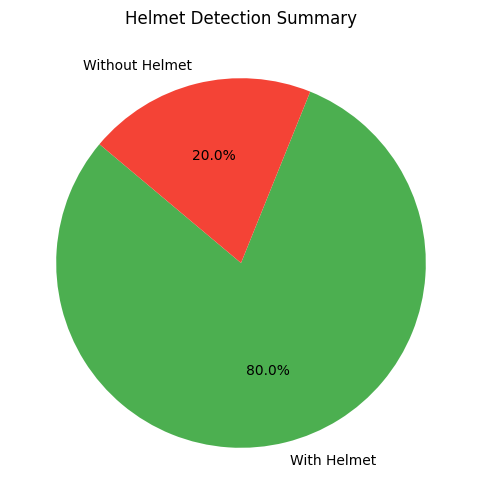

📊 Summary chart saved to: /content/drive/MyDrive/helmet_detection_project/runs/detect/helmet_violation_summary/helmet_violation_summary_chart.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 3 - Visualization (Pie chart)

labels = ['With Helmet', 'Without Helmet']
values = [counts.get(0, 0), counts.get(1, 0)]
colors = ['#4CAF50', '#F44336']  # green for safe, red for violation

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Helmet Detection Summary')
plt.show()

# Save the chart
chart_path = os.path.join(results_dir, "helmet_violation_summary_chart.png")
plt.savefig(chart_path)
print(f"📊 Summary chart saved to: {chart_path}")


In [ ]:
# Step 4 - Summary text output
total = sum(values)
with_helmet = counts.get(0, 0)
without_helmet = counts.get(1, 0)
violation_rate = (without_helmet / total) * 100 if total > 0 else 0

print("📄 Helmet Detection Summary Report")
print(f"Total riders detected: {total}")
print(f"With Helmet: {with_helmet}")
print(f"Without Helmet (Violations): {without_helmet}")
print(f"Helmet Violation Rate: {violation_rate:.2f}%")


📄 Helmet Detection Summary Report
Total riders detected: 15
With Helmet: 12
Without Helmet (Violations): 3
Helmet Violation Rate: 20.00%


In [ ]:
# === IMPORTS ===
import os, glob, sys, math, shutil
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import warnings
warnings.filterwarnings("ignore")

# === CONFIG ===
DRIVE_BASE = "/content/drive/MyDrive/helmet_detection_project"   # your project folder in Drive
MODEL_SEARCH_DIR = os.path.join(DRIVE_BASE, "runs")              # where to search for .pt weights
TEST_IMAGES_DIR = os.path.join(DRIVE_BASE, "test_images")        # images to run inference on
OUTPUT_RUN_DIR = os.path.join(DRIVE_BASE, "runs", "detect_summary")  # where outputs will be saved
CONF_THRESHOLD = 0.25
VIOLATION_RATE_ALERT = 0.25
VIOLATION_COUNT_ALERT = 10

# === SETUP YOLO ===
try:
    from ultralytics import YOLO
except Exception:
    print("Installing ultralytics...")
    !pip install -q ultralytics
    from ultralytics import YOLO

# === FIND MODEL WEIGHTS ===
def find_best_weights(search_root):
    candidates = []
    for root, dirs, files in os.walk(search_root):
        for f in files:
            if f.endswith(".pt"):
                candidates.append(os.path.join(root, f))
    bests = [p for p in candidates if os.path.basename(p) == "best.pt"]
    if bests:
        return bests[-1]
    return candidates[-1] if candidates else None

print("Searching for model weights under:", MODEL_SEARCH_DIR)
WEIGHT = find_best_weights(MODEL_SEARCH_DIR)
if WEIGHT is None:
    raise FileNotFoundError(f"No .pt weights found under {MODEL_SEARCH_DIR}. Place your best .pt there or set WEIGHT manually.")
print("✅ Using model:", WEIGHT)

# === LOAD MODEL ===
model = YOLO(WEIGHT)

# === COLLECT IMAGES ===
img_patterns = [os.path.join(TEST_IMAGES_DIR, "*.png"),
                os.path.join(TEST_IMAGES_DIR, "*.jpg"),
                os.path.join(TEST_IMAGES_DIR, "*.jpeg")]
images = []
for p in img_patterns:
    images += glob.glob(p)
images = sorted(images)

if len(images) == 0:
    raise FileNotFoundError(f"No images found in {TEST_IMAGES_DIR}. Please upload test images (PNG/JPG) to that folder first.")
print(f"📸 Found {len(images)} images to run inference on.")

# === RUN INFERENCE ===
rows = []
annotated_save_dir = os.path.join(OUTPUT_RUN_DIR, "predictions")
os.makedirs(annotated_save_dir, exist_ok=True)

print("Running predictions (please wait)...")
for img_path in images:
    res = model.predict(source=img_path, imgsz=640, conf=CONF_THRESHOLD, save=True,
                        save_dir=annotated_save_dir, exist_ok=True)
    r = res[0]
    names = r.names
    classes = list(r.boxes.cls.cpu().numpy()) if len(r.boxes) else []
    confs = list(r.boxes.conf.cpu().numpy()) if len(r.boxes) else []
    counts = Counter()
    for c in classes:
        clsname = names[int(c)]
        counts[clsname] += 1
    avg_conf = float(np.mean(confs)) if len(confs) > 0 else 0.0
    mtime = os.path.getmtime(img_path)
    hour = datetime.datetime.fromtimestamp(mtime).hour
    base = os.path.splitext(os.path.basename(img_path))[0]
    annotated_candidates = glob.glob(os.path.join(annotated_save_dir, "**", base + "*"), recursive=True)
    annotated_file = annotated_candidates[0] if annotated_candidates else None
    rows.append({
        "image": os.path.basename(img_path),
        "path": img_path,
        "annotated": annotated_file,
        "with_helmet": counts.get("With Helmet", 0),
        "without_helmet": counts.get("Without Helmet", 0),
        "total_detections": len(classes),
        "avg_conf": avg_conf,
        "hour": hour
    })

df = pd.DataFrame(rows)
os.makedirs(OUTPUT_RUN_DIR, exist_ok=True)
df.to_csv(os.path.join(OUTPUT_RUN_DIR, "detection_summary.csv"), index=False)
print("📁 Saved detection_summary.csv ->", os.path.join(OUTPUT_RUN_DIR, "detection_summary.csv"))

# === COMPUTE TOTALS ===
tot_with = df["with_helmet"].sum()
tot_without = df["without_helmet"].sum()
tot = tot_with + tot_without
safety_score = (tot_with / tot) * 100 if tot > 0 else 0.0
print(f"\n🪖 With Helmet: {tot_with}\n❌ Without Helmet: {tot_without}\n📊 Total detections: {tot}")
print(f"🧠 Helmet Safety Score: {safety_score:.2f}/100")

# === ALERT LOGIC ===
alerts = []
if tot_without > VIOLATION_COUNT_ALERT:
    alerts.append(f"High number of violations: {tot_without}")
if tot > 0 and (tot_without / tot) > VIOLATION_RATE_ALERT:
    alerts.append(f"High violation rate: {tot_without}/{tot} = {(tot_without/tot):.2f}")

if alerts:
    print("\n🚨 ALERTS:")
    for a in alerts:
        print("   -", a)
else:
    print("\n✅ No alerts triggered.")

# === VISUALIZATIONS ===
# Pie chart
plt.figure(figsize=(6,6))
plt.pie([tot_with, tot_without], labels=["With Helmet", "Without Helmet"],
        autopct=lambda p: f"{p:.1f}%\n({int(p*tot/100)})", startangle=90)
plt.title("Helmet vs No-Helmet Ratio")
pie_path = os.path.join(OUTPUT_RUN_DIR, "pie_chart.png")
plt.savefig(pie_path)
plt.close()
print("📊 Pie chart saved ->", pie_path)

# Hourly bar chart
hourly = df.groupby("hour")[["with_helmet","without_helmet"]].sum().sort_index()
if len(hourly) > 0:
    ax = hourly.plot(kind="bar", stacked=True, figsize=(10,5))
    plt.title("Hourly Helmet Usage Trend")
    plt.xlabel("Hour of Day")
    plt.ylabel("Count")
    bar_path = os.path.join(OUTPUT_RUN_DIR, "hourly_usage.png")
    plt.tight_layout()
    plt.savefig(bar_path)
    plt.close()
    print("📈 Hourly chart saved ->", bar_path)
else:
    print("No hourly data (timestamps missing).")

print("\n✅ Visualization + alert logic complete.")
print("Results folder:", OUTPUT_RUN_DIR)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Searching for model weights under: /content/drive/MyDrive/helmet_detection_project/runs
✅ Using model: /content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt
📸 Found 5 images to run inference on.
Running predictions (please wait)...

image 1/1 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets113.png: 480x640 1 With Helmet, 1 Without Helmet, 481.4ms
Speed: 20.3ms preprocess, 481.4ms inference, 41.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/test_images/BikesHelmets277.png: 384x640 7 With Helmets, 239.4ms
Speed: 3.0ms preprocess,

In [ ]:

import os, glob, math
from pathlib import Path
import pprint
import sys

# === EDIT NOTHING BELOW UNLESS YOU KNOW WHAT YOU'RE CHANGING ===
DRIVE_BASE = "/content/drive/MyDrive/helmet_detection_project"   # your Drive project folder
MODEL_SEARCH_DIR = os.path.join(DRIVE_BASE, "runs")             # where runs are saved
TEST_IMAGES_DIR = os.path.join(DRIVE_BASE, "helmet-yolo", "images", "val")  # typical location
OUTPUT_RUN_DIR = os.path.join(DRIVE_BASE, "runs", "detect_summary")  # where we'll save outputs
os.makedirs(OUTPUT_RUN_DIR, exist_ok=True)

print("Drive base:", DRIVE_BASE)
print("Model search dir:", MODEL_SEARCH_DIR)
print("Test images dir:", TEST_IMAGES_DIR)
print("Output run dir:", OUTPUT_RUN_DIR)

# install ultralytics if not present
try:
    import ultralytics
except Exception:
    print("Installing ultralytics...")
    !pip -q install ultralytics
    import ultralytics

from ultralytics import YOLO

# find .pt files (prioritize 'best.pt')
pt_files = []
for root, dirs, files in os.walk(MODEL_SEARCH_DIR):
    for f in files:
        if f.endswith(".pt"):
            pt_files.append(os.path.join(root, f))
pt_files = sorted(pt_files)
bests = [p for p in pt_files if os.path.basename(p) == "best.pt"]
WEIGHT = bests[-1] if bests else (pt_files[-1] if pt_files else None)

print("\nFound .pt files (up to 20):")
pprint.pprint(pt_files[:20])
print("\nSelected checkpoint to use:")
print(WEIGHT)

if WEIGHT is None:
    raise FileNotFoundError(f"No .pt weights found under {MODEL_SEARCH_DIR}. Put your best.pt there or set WEIGHT manually.")

# quick check of val images
img_glob = sorted(glob.glob(os.path.join(TEST_IMAGES_DIR, "*.png")) + glob.glob(os.path.join(TEST_IMAGES_DIR, "*.jpg")))
print(f"\nFound {len(img_glob)} validation images, showing first 6:")
for p in img_glob[:6]:
    print(" -", p)

# Save a small helper file with paths so next cells reuse exact values
meta = {
    "DRIVE_BASE": DRIVE_BASE,
    "MODEL_SEARCH_DIR": MODEL_SEARCH_DIR,
    "TEST_IMAGES_DIR": TEST_IMAGES_DIR,
    "OUTPUT_RUN_DIR": OUTPUT_RUN_DIR,
    "WEIGHT": WEIGHT
}
import json
with open(os.path.join(OUTPUT_RUN_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("\nWrote", os.path.join(OUTPUT_RUN_DIR, "meta.json"))


Drive base: /content/drive/MyDrive/helmet_detection_project
Model search dir: /content/drive/MyDrive/helmet_detection_project/runs
Test images dir: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val
Output run dir: /content/drive/MyDrive/helmet_detection_project/runs/detect_summary

Found .pt files (up to 20):
['/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt',
 '/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/last.pt']

Selected checkpoint to use:
/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt

Found 153 validation images, showing first 6:
 - /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png
 - /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png
 - /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets113.png
 - /content/drive/MyDrive/helmet_detection_projec

In [ ]:
# CELL 2: Run inference, save annotated images to Drive, collect bbox centers and CSV
import json, os, glob, math
from collections import defaultdict
import numpy as np
import pandas as pd
from ultralytics import YOLO

# load meta
meta_path = os.path.join("/content/drive/MyDrive/helmet_detection_project", "runs", "detect_summary", "meta.json")
if not os.path.exists(meta_path):
    # fallback to OUTPUT_RUN_DIR used in prior cell
    meta_path = os.path.join("/content/drive/MyDrive/helmet_detection_project", "runs", "detect_summary", "meta.json")
print("Using meta:", meta_path)
meta = json.load(open(meta_path))

WEIGHT = meta["WEIGHT"]
TEST_IMAGES_DIR = meta["TEST_IMAGES_DIR"]
OUTPUT_RUN_DIR = meta["OUTPUT_RUN_DIR"]

print("WEIGHT:", WEIGHT)
print("TEST_IMAGES_DIR:", TEST_IMAGES_DIR)
print("OUTPUT_RUN_DIR:", OUTPUT_RUN_DIR)

model = YOLO(WEIGHT)

save_ann_dir = os.path.join(OUTPUT_RUN_DIR, "predictions")
os.makedirs(save_ann_dir, exist_ok=True)

img_paths = sorted(glob.glob(os.path.join(TEST_IMAGES_DIR, "*.png")) + glob.glob(os.path.join(TEST_IMAGES_DIR, "*.jpg")))
print("Images to run:", len(img_paths))
if len(img_paths) == 0:
    raise FileNotFoundError(f"No images found at {TEST_IMAGES_DIR} - update TEST_IMAGES_DIR and re-run Cell 1.")

rows = []
centers = []  # list of (x_norm, y_norm) for 'Without Helmet'
for p in img_paths:
    r = model.predict(source=p, imgsz=640, conf=0.25, save=True, save_dir=save_ann_dir, exist_ok=True)[0]
    # r.boxes: can be empty
    names = r.names  # dict idx->name
    if len(r.boxes) == 0:
        rows.append({"image": os.path.basename(p), "with_helmet":0, "without_helmet":0, "total":0})
        continue
    boxes = r.boxes.xyxy.cpu().numpy()  # [N,4] x1,y1,x2,y2 in pixels (original image)
    cls_ids = r.boxes.cls.cpu().numpy().astype(int)  # class ids
    confs = r.boxes.conf.cpu().numpy()
    h,w = r.orig_shape[:2]  # original image height, width
    with_cnt = 0
    without_cnt = 0
    for (x1,y1,x2,y2), cid, conf in zip(boxes, cls_ids, confs):
        cname = names[int(cid)]
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        # normalize center to 0..1 using width/height
        x_norm = cx / w
        y_norm = cy / h
        if cname.lower().startswith("without"):  # handle label naming variation
            without_cnt += 1
            centers.append((x_norm, y_norm))
        elif cname.lower().startswith("with"):
            with_cnt += 1
    rows.append({"image": os.path.basename(p), "with_helmet":with_cnt, "without_helmet":without_cnt, "total": with_cnt+without_cnt})

# save CSV
df = pd.DataFrame(rows)
csv_path = os.path.join(OUTPUT_RUN_DIR, "detection_summary.csv")
df.to_csv(csv_path, index=False)
print("Saved detection CSV ->", csv_path)

# save centers as npz for heatmap generation
centers_arr = np.array(centers) if len(centers)>0 else np.zeros((0,2))
npz_path = os.path.join(OUTPUT_RUN_DIR, "without_centers.npz")
np.savez_compressed(npz_path, centers=centers_arr)
print("Saved centers ->", npz_path)
print("Number of 'Without Helmet' detections collected:", centers_arr.shape[0])
print("Annotated images saved into:", save_ann_dir)


Using meta: /content/drive/MyDrive/helmet_detection_project/runs/detect_summary/meta.json
WEIGHT: /content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt
TEST_IMAGES_DIR: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val
OUTPUT_RUN_DIR: /content/drive/MyDrive/helmet_detection_project/runs/detect_summary
Images to run: 153

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png: 480x640 1 With Helmet, 189.5ms
Speed: 3.1ms preprocess, 189.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png: 384x640 1 With Helmet, 149.3ms
Speed: 2.1ms preprocess, 149.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHel

Loaded centers shape: (148, 2)
Overlaying heatmap on: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png
Saved heatmap -> /content/drive/MyDrive/helmet_detection_project/runs/detect_summary/heatmap.png
Saved overlay -> /content/drive/MyDrive/helmet_detection_project/runs/detect_summary/heatmap_overlay.png


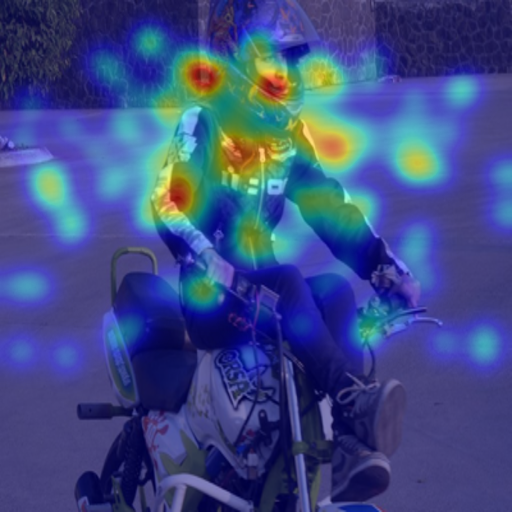

In [ ]:
# CELL 3: Build heatmap overlay from centers and save to Drive
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image

OUTPUT_RUN_DIR = "/content/drive/MyDrive/helmet_detection_project/runs/detect_summary"
npz_path = os.path.join(OUTPUT_RUN_DIR, "without_centers.npz")
if not os.path.exists(npz_path):
    raise FileNotFoundError("Centers file not found: " + npz_path)

data = np.load(npz_path)
centers = data["centers"]  # shape [N,2], (x_norm, y_norm)
print("Loaded centers shape:", centers.shape)

if centers.shape[0] == 0:
    print("No 'Without Helmet' centers collected — heatmap would be empty. Check predictions in the predictions folder.")
else:
    # Heatmap grid size (choose reasonable resolution)
    H = 512
    W = 512
    heat = np.zeros((H, W), dtype=np.float32)

    # convert normalized centers to pixel coords on the HxW grid
    for (x_norm, y_norm) in centers:
        # clip to [0,1]
        x_norm = float(max(0.0, min(1.0, x_norm)))
        y_norm = float(max(0.0, min(1.0, y_norm)))
        xi = int(x_norm * (W-1))
        yi = int(y_norm * (H-1))
        # add a Gaussian blob — faster approximate by adding a small disk and smoothing later
        rr = 10  # radius of blob in pixels on heatmap grid; adjust if too small/large
        x0 = max(0, xi-rr); x1 = min(W, xi+rr+1)
        y0 = max(0, yi-rr); y1 = min(H, yi+rr+1)
        heat[y0:y1, x0:x1] += 1.0

    # smooth the heatmap with Gaussian to create density
    heat = cv2.GaussianBlur(heat, ksize=(0,0), sigmaX=12, sigmaY=12)
    # normalize to 0..1
    heat = heat - heat.min()
    if heat.max() > 0:
        heat = heat / heat.max()

    # Choose a sample image to overlay (use first annotated image if available)
    predictions_dir = os.path.join(OUTPUT_RUN_DIR, "predictions")
    candidate = None
    for root, dirs, files in os.walk(predictions_dir):
        for f in sorted(files):
            if f.lower().endswith((".jpg", ".png")):
                candidate = os.path.join(root, f)
                break
        if candidate:
            break

    if candidate is None:
        # fallback to any val image (change path if needed)
        candidate = sorted(glob.glob("/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/*.png") +
                           glob.glob("/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/*.jpg"))[0]
    print("Overlaying heatmap on:", candidate)

    # load image and resize to W x H for overlay (but also save overlay at both sizes)
    img = Image.open(candidate).convert("RGB")
    img_small = img.resize((W, H))
    img_np = np.array(img_small).astype(np.uint8)

    # create color map for heat (jet-like)
    cmap = plt.get_cmap("jet")
    heat_rgb = (cmap(heat)[:, :, :3] * 255).astype(np.uint8)

    # overlay: alpha blend
    alpha = 0.5
    overlay = (img_np * (1-alpha) + heat_rgb * alpha).astype(np.uint8)

    # save overlays
    overlay_path = os.path.join(OUTPUT_RUN_DIR, "heatmap_overlay.png")
    Image.fromarray(overlay).save(overlay_path)
    # also save pure heatmap
    heat_path = os.path.join(OUTPUT_RUN_DIR, "heatmap.png")
    Image.fromarray((heat*255).astype(np.uint8)).save(heat_path)

    print("Saved heatmap ->", heat_path)
    print("Saved overlay ->", overlay_path)

    # Display inline (Colab image display)
    from IPython.display import display
    display(Image.open(overlay_path))


In [1]:
# Cell 1 — Setup
# Run this first. Edit nothing here unless you know what you're doing.

# Install ultralytics if missing
import importlib, sys, os
try:
    import ultralytics
except Exception:
    !pip install -q ultralytics
    import ultralytics

# Other libs
!pip install -q seaborn  # optional for nicer plots
import glob, json, math, shutil, time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from datetime import datetime
from ultralytics import YOLO
print("Setup complete.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete.


In [2]:
# Cell 2 — CONFIG (edit only these paths if different)
DRIVE_BASE = "/content/drive/MyDrive/helmet_detection_project"   # your project folder
MODEL_PATH = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
IMAGES_DIR = "/content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val"  # images to analyze
OUTPUT_RUN_DIR = os.path.join(DRIVE_BASE, "runs", "detect_analysis")  # where results & plots will be saved

# Violation system params
NO_HELMET_CLASS_NAME = "Without Helmet"   # exact classname in your model.names
VIOLATION_COUNT_THRESHOLD = 2  # images with >= this many no-helmet detections will be saved as violation
CONF_THRESHOLD_SAVE = 0.25     # optional: ignore detections below this confidence for counting

# Create output dirs
os.makedirs(OUTPUT_RUN_DIR, exist_ok=True)
VIOLATIONS_DIR = os.path.join(OUTPUT_RUN_DIR, "violations")
os.makedirs(VIOLATIONS_DIR, exist_ok=True)
print("CONFIG:\n", "MODEL_PATH:", MODEL_PATH, "\nIMAGES_DIR:", IMAGES_DIR, "\nOUTPUT_RUN_DIR:", OUTPUT_RUN_DIR)


CONFIG:
 MODEL_PATH: /content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt 
IMAGES_DIR: /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val 
OUTPUT_RUN_DIR: /content/drive/MyDrive/helmet_detection_project/runs/detect_analysis


In [3]:
# Cell 3 — quick checks
assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.isdir(IMAGES_DIR), f"Images dir not found: {IMAGES_DIR}"
print("Paths look good.")


Paths look good.


In [4]:
# Cell 4 — Run inference and collect data (may take some minutes depending on images)
model = YOLO(MODEL_PATH)  # load model

image_paths = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.*")))
print(f"Found {len(image_paths)} images.")

rows = []
saved_pred_dirs = []  # store where predictions saved

for i, img_path in enumerate(image_paths, 1):
    # run prediction; save=True will write annotated image to runs/detect/predict by default
    results = model.predict(img_path, imgsz=640, conf=0.001, save=True)  # low conf to capture everything; we filter later
    r = results[0]
    save_dir = str(r.save_dir)  # where ultralytics saved annotated image
    saved_pred_dirs.append(save_dir)
    # Build structured row
    # get file timestamp (modification time) -> datetime
    mtime = os.path.getmtime(img_path)
    timestamp = datetime.fromtimestamp(mtime)
    classes = []
    boxes = []
    confidences = []
    # r.boxes.xyxy, .cls, .conf are tensors
    if hasattr(r, "boxes") and len(r.boxes):
        xyxy = r.boxes.xyxy.numpy()  # Nx4
        cls_ids = r.boxes.cls.numpy().astype(int)  # Nx
        confs = r.boxes.conf.numpy()
        for b, cid, conf in zip(xyxy, cls_ids, confs):
            # map class id to name
            cls_name = r.names[int(cid)]
            if conf < CONF_THRESHOLD_SAVE:
                continue
            classes.append(cls_name)
            boxes.append([float(x) for x in b.tolist()])  # [x1,y1,x2,y2]
            confidences.append(float(conf))
    # counts by class
    count_dict = {}
    for cname in r.names.values():
        count_dict[cname] = classes.count(cname)
    avg_conf = float(np.mean(confidences)) if confidences else 0.0
    rows.append({
        "image": os.path.basename(img_path),
        "path": img_path,
        "timestamp": timestamp,
        "classes": classes,
        "boxes": boxes,
        "confidences": confidences,
        "avg_confidence": avg_conf,
        **count_dict
    })
    if i % 50 == 0 or i==len(image_paths):
        print(f"{i}/{len(image_paths)} processed.")

# DataFrame
df = pd.DataFrame(rows)
csv_out = os.path.join(OUTPUT_RUN_DIR, "predictions_summary.csv")
df.to_csv(csv_out, index=False)
print("Saved summary to", csv_out)


Found 153 images.

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets1.png: 480x640 9 With Helmets, 3 Without Helmets, 399.6ms
Speed: 21.8ms preprocess, 399.6ms inference, 36.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets101.png: 384x640 7 With Helmets, 4 Without Helmets, 253.1ms
Speed: 6.1ms preprocess, 253.1ms inference, 3.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesHelmets113.png: 480x640 6 With Helmets, 5 Without Helmets, 302.2ms
Speed: 6.2ms preprocess, 302.2ms inference, 6.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict

image 1/1 /content/drive/MyDrive/helmet_detection_project/helmet-yolo/images/val/BikesH

In [5]:
# Cell 5 — Violation saver
violation_log = []
for idx, row in df.iterrows():
    no_helmet_count = row.get(NO_HELMET_CLASS_NAME, 0)
    if no_helmet_count >= VIOLATION_COUNT_THRESHOLD:
        src = row["path"]
        dst_name = f"{os.path.splitext(row['image'])[0]}_viol_{no_helmet_count}.jpg"
        dst = os.path.join(VIOLATIONS_DIR, dst_name)
        # copy the annotated prediction if exists (use last saved result location)
        # we try to locate an annotated image in saved_pred_dirs
        # simplest: copy original image as violation snapshot AND save bbox info
        shutil.copy2(src, dst)
        violation_log.append({
            "image": row['image'],
            "src": src,
            "saved_violation_image": dst,
            "timestamp": row["timestamp"],
            "no_helmet_count": no_helmet_count,
            "avg_conf": row["avg_confidence"]
        })

viol_df = pd.DataFrame(violation_log)
viol_csv = os.path.join(VIOLATIONS_DIR, "violations_log.csv")
if not viol_df.empty:
    viol_df.to_csv(viol_csv, index=False)
print(f"Saved {len(violation_log)} violation snapshots to {VIOLATIONS_DIR} and log to {viol_csv}")


Saved 29 violation snapshots to /content/drive/MyDrive/helmet_detection_project/runs/detect_analysis/violations and log to /content/drive/MyDrive/helmet_detection_project/runs/detect_analysis/violations/violations_log.csv


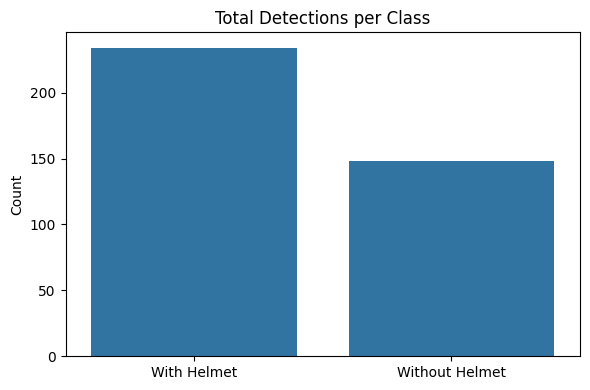

Saved bar chart to /content/drive/MyDrive/helmet_detection_project/runs/detect_analysis/bar_class_counts.png


In [6]:
# Cell 6 — Bar chart of total detections per class
# Sum counts across dataset
class_cols = [c for c in df.columns if c not in ["image","path","timestamp","classes","boxes","confidences","avg_confidence"]]
# If class_cols are weird, fallback to keys in r.names
if len(class_cols)==0:
    # get names from model
    class_cols = [model.names[i] for i in model.names]

agg = {}
for c in class_cols:
    agg[c] = df[c].sum() if c in df.columns else 0

plt.figure(figsize=(6,4))
sns.barplot(x=list(agg.keys()), y=list(agg.values()))
plt.title("Total Detections per Class")
plt.ylabel("Count")
plt.xlabel("")
plt.tight_layout()
barfile = os.path.join(OUTPUT_RUN_DIR, "bar_class_counts.png")
plt.savefig(barfile)
plt.show()
print("Saved bar chart to", barfile)


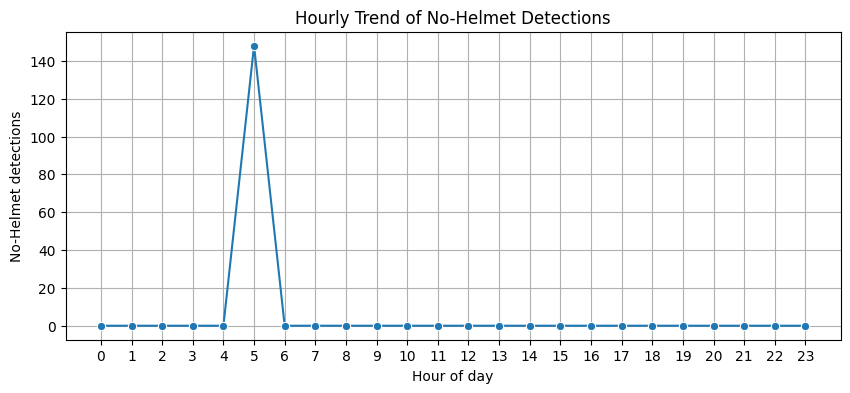

Saved hourly trend to /content/drive/MyDrive/helmet_detection_project/runs/detect_analysis/hourly_nohelmet_trend.png


In [7]:
# Cell 7 — Hourly trend for no-helmet detections
df['hour'] = df['timestamp'].dt.hour
hourly = df.groupby('hour')[NO_HELMET_CLASS_NAME].sum().reindex(range(24), fill_value=0)

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o")
plt.xticks(range(0,24))
plt.xlabel("Hour of day")
plt.ylabel("No-Helmet detections")
plt.title("Hourly Trend of No-Helmet Detections")
plt.grid(True)
hourfile = os.path.join(OUTPUT_RUN_DIR, "hourly_nohelmet_trend.png")
plt.savefig(hourfile)
plt.show()
print("Saved hourly trend to", hourfile)


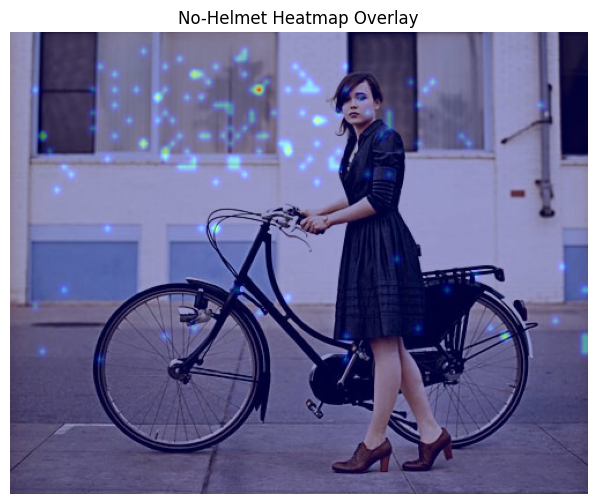

Saved heatmap overlay to /content/drive/MyDrive/helmet_detection_project/runs/detect_analysis/nohelmet_heatmap_overlay.jpg


In [8]:
# Cell 8 — Heatmap overlay (simple grid heatmap of bbox centers)
# Choose a reference image for overlay (middle image)
if len(df)==0:
    raise SystemExit("No predictions found in df.")
ref_img_path = df.iloc[len(df)//2]["path"]
img = cv2.imread(ref_img_path)
H, W = img.shape[:2]

# heatmap resolution (coarser grid for speed)
GRID_X, GRID_Y = 80, 60  # adjust for smoother heatmap
heatmap = np.zeros((GRID_Y, GRID_X), dtype=np.float32)

# For each row, for each no-helmet box, add to heatmap by center
for _, row in df.iterrows():
    boxes = row["boxes"]
    classes = row["classes"]
    confs = row["confidences"]
    if not boxes:
        continue
    for b, cls_name, conf in zip(boxes, classes, confs):
        if cls_name == NO_HELMET_CLASS_NAME:
            x1,y1,x2,y2 = b
            cx = int((x1+x2)/2)
            cy = int((y1+y2)/2)
            gx = int(cx / W * GRID_X)
            gy = int(cy / H * GRID_Y)
            gx = np.clip(gx, 0, GRID_X-1)
            gy = np.clip(gy, 0, GRID_Y-1)
            heatmap[gy, gx] += 1.0

# normalize and resize to image size
if heatmap.max() > 0:
    heatmap_norm = (heatmap / heatmap.max() * 255).astype(np.uint8)
else:
    heatmap_norm = heatmap.astype(np.uint8)
heatmap_big = cv2.resize(heatmap_norm, (W, H), interpolation=cv2.INTER_LINEAR)
heatmap_color = cv2.applyColorMap(heatmap_big, cv2.COLORMAP_JET)

# overlay
overlayed = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)
heatfile = os.path.join(OUTPUT_RUN_DIR, "nohelmet_heatmap_overlay.jpg")
cv2.imwrite(heatfile, overlayed)
# also save heatmap alone
heatmap_vis_file = os.path.join(OUTPUT_RUN_DIR, "nohelmet_heatmap_raw.png")
cv2.imwrite(heatmap_vis_file, heatmap_big)

# show
from matplotlib import pyplot as plt
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title("No-Helmet Heatmap Overlay")
plt.show()
print("Saved heatmap overlay to", heatfile)


In [12]:
# Colab-friendly "alert listener" (no network)
import json
from datetime import datetime

def handle_alert(payload):
    """Directly print and log alerts inside Colab."""
    print(f"\n[{datetime.now().isoformat()}] 🚨 ALERT TRIGGERED:")
    print(json.dumps(payload, indent=2))
    with open("/content/helmet_alert_log.txt", "a") as f:
        f.write(datetime.now().isoformat() + " " + json.dumps(payload) + "\n")

print("✅ Colab alert handler ready (no sockets needed).")


✅ Colab alert handler ready (no sockets needed).


In [14]:
# 2) Video detection loop with overlay + alert integration (run after cell 1)
import os, time, cv2, numpy as np
from ultralytics import YOLO

# ------------------ CONFIG (edit these) ------------------
# Path to your trained .pt weights. Example from your Drive:
MODEL_PATH = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
# Video source: file path in Drive OR integer for webcam (0)
SOURCE = "/content/drive/MyDrive/helmet_detection_project/test_images/Helmet detection video 1.mp4"  # change to your video, or "0" for webcam
# Where to save output (will be created if needed)
OUTPUT_DIR = "/content/drive/MyDrive/helmet_detection_project/runs/detect/predict_with_alerts"
# --------------------------------------------------------

# Alert rules (tweak)
ALERT_COUNT_THRESHOLD = 2         # >= this many "Without Helmet" in a single frame triggers alert
ALERT_COOLDOWN_SECS = 12         # seconds between alerts (prevents repeated alerts)
CONF_THRESHOLD = 0.30            # detection confidence threshold
CLASS_NO_HELMET = None           # we'll set based on model.names below (if you used 0/1 order)

# safety checks
assert os.path.exists(MODEL_PATH), f"Weight not found: {MODEL_PATH}"

os.makedirs(OUTPUT_DIR, exist_ok=True)
out_video_path = os.path.join(OUTPUT_DIR, "output_with_alerts.mp4")

# Load model
model = YOLO(MODEL_PATH)
print("Model loaded. Names:", model.names)

# Determine which class index corresponds to "Without Helmet"
# If you used 'With Helmet' then 'Without Helmet' in that order previously, index likely 1.
if CLASS_NO_HELMET is None:
    for k,v in model.names.items():
        if "without" in v.lower() or "no helmet" in v.lower() or "no_helmet" in v.lower():
            CLASS_NO_HELMET = k
            break
    if CLASS_NO_HELMET is None:
        # fallback: if names exactly like earlier conversation, pick index 1
        CLASS_NO_HELMET = 1
print("Using class index for NO-HELMET =", CLASS_NO_HELMET, "label:", model.names.get(CLASS_NO_HELMET, "unknown"))

# Open source
if str(SOURCE).isdigit():
    cap = cv2.VideoCapture(int(SOURCE))
else:
    cap = cv2.VideoCapture(SOURCE)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open source: {SOURCE}")

# prepare VideoWriter (match input fps and size)
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out_writer = cv2.VideoWriter(out_video_path, fourcc, fps, (w, h))

last_alert_time = 0
frame_idx = 0
start_time = time.time()

print("Starting detection. Press Ctrl+C to stop early (if running interactively).")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        # run model on current frame (use batch of single frame)
        # returns a list-like; results[0] corresponds to this frame
        results = model.predict(frame, imgsz=640, conf=CONF_THRESHOLD, verbose=False)
        r = results[0]

        # parse detections
        boxes = r.boxes.xyxy.cpu().numpy() if hasattr(r.boxes, "xyxy") else np.array([])
        confs = r.boxes.conf.cpu().numpy() if hasattr(r.boxes, "conf") else np.array([])
        cls_idx = r.boxes.cls.cpu().numpy().astype(int) if hasattr(r.boxes, "cls") else np.array([])

        # count no-helmet detections and gather boxes for overlay
        nohelmet_inds = [i for i,c in enumerate(cls_idx) if int(c) == int(CLASS_NO_HELMET)]
        nohelmet_count = len(nohelmet_inds)
        avg_conf = float(np.mean(confs[nohelmet_inds])) if nohelmet_count>0 else 0.0

        # draw bounding boxes and labels
        for i, (xy, c, cf) in enumerate(zip(boxes, cls_idx, confs)):
            x1,y1,x2,y2 = map(int, xy[:4])
            cls_name = model.names.get(int(c), str(int(c)))
            label = f"{cls_name} {cf:.2f}"
            # color: red for no-helmet, green otherwise
            color = (0,0,255) if int(c)==int(CLASS_NO_HELMET) else (0,255,0)
            cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
            # label background
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(frame, (x1, y1-18), (x1+tw, y1), color, -1)
            cv2.putText(frame, label, (x1, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

        # If violation threshold reached and cooldown passed -> alert
        now = time.time()
        if (nohelmet_count >= ALERT_COUNT_THRESHOLD) and (now - last_alert_time > ALERT_COOLDOWN_SECS):
            payload = {
                "event": "helmet_violation",
                "timestamp": datetime.utcnow().isoformat() + "Z",
                "frame_idx": int(frame_idx),
                "no_helmet_count": int(nohelmet_count),
                "avg_conf": float(round(avg_conf, 3)),
                "example_boxes": [list(map(int, boxes[i][:4])) for i in nohelmet_inds[:6]]
            }
            handle_alert(payload)
            last_alert_time = now
            # Visual alert overlay (big red banner)
            banner_text = "🚨 HELMET VIOLATION DETECTED"
            cv2.rectangle(frame, (0,0), (w,60), (0,0,255), -1)
            cv2.putText(frame, banner_text, (15,40), cv2.FONT_HERSHEY_DUPLEX, 1.0, (255,255,255), 2, cv2.LINE_AA)

        # write frame to output video
        out_writer.write(frame)

        # optional: show in notebook (slower). Uncomment if you want live display (not recommended for long videos)
        # from google.colab.patches import cv2_imshow
        # if frame_idx % 5 == 0: cv2_imshow(frame)

    duration = time.time() - start_time
    print(f"\nDone. Processed {frame_idx} frames in {duration:.1f}s (~{frame_idx/duration:.1f} FPS).")
    print("Saved output video to:", out_video_path)

finally:
    cap.release()
    out_writer.release()


Model loaded. Names: {0: 'With Helmet', 1: 'Without Helmet'}
Using class index for NO-HELMET = 1 label: Without Helmet
Starting detection. Press Ctrl+C to stop early (if running interactively).


/tmp/ipython-input-197598195.py:104: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",



[2025-11-02T15:46:57.264000] 🚨 ALERT TRIGGERED:
{
  "event": "helmet_violation",
  "timestamp": "2025-11-02T15:46:57.263944Z",
  "frame_idx": 6,
  "no_helmet_count": 3,
  "avg_conf": 0.414,
  "example_boxes": [
    [
      139,
      57,
      175,
      99
    ],
    [
      413,
      88,
      459,
      140
    ],
    [
      377,
      85,
      412,
      131
    ]
  ]
}

[2025-11-02T15:47:11.254652] 🚨 ALERT TRIGGERED:
{
  "event": "helmet_violation",
  "timestamp": "2025-11-02T15:47:11.254600Z",
  "frame_idx": 80,
  "no_helmet_count": 2,
  "avg_conf": 0.402,
  "example_boxes": [
    [
      279,
      77,
      339,
      155
    ],
    [
      23,
      75,
      64,
      123
    ]
  ]
}

[2025-11-02T15:47:29.929890] 🚨 ALERT TRIGGERED:
{
  "event": "helmet_violation",
  "timestamp": "2025-11-02T15:47:29.929858Z",
  "frame_idx": 183,
  "no_helmet_count": 2,
  "avg_conf": 0.433,
  "example_boxes": [
    [
      84,
      64,
      141,
      133
    ],
    [
      5,
      74,


In [15]:
test_payload = {
    "event": "helmet_violation",
    "timestamp": datetime.utcnow().isoformat() + "Z",
    "frame_idx": 1,
    "no_helmet_count": 3,
    "avg_conf": 0.92,
    "example_boxes": [[10,20,100,200]]
}
handle_alert(test_payload)



[2025-11-02T15:50:43.941662] 🚨 ALERT TRIGGERED:
{
  "event": "helmet_violation",
  "timestamp": "2025-11-02T15:50:43.941379Z",
  "frame_idx": 1,
  "no_helmet_count": 3,
  "avg_conf": 0.92,
  "example_boxes": [
    [
      10,
      20,
      100,
      200
    ]
  ]
}


/tmp/ipython-input-1528846030.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",


In [16]:
# Replace your previous detection loop with this cell
import os, time, cv2, numpy as np
from ultralytics import YOLO
from datetime import datetime

# ------------------ CONFIG (edit these) ------------------
MODEL_PATH = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
SOURCE = "/content/drive/MyDrive/helmet_detection_project/test_images/Helmet detection video 1.mp4"  # or "0" for webcam
OUTPUT_DIR = "/content/drive/MyDrive/helmet_detection_project/runs/detect/predict_with_alerts_consec"
# Alert params
ALERT_COUNT_THRESHOLD = 2         # detections in a single frame considered a violation
CONSECUTIVE_FRAMES_REQUIRED = 3   # require this many consecutive frames of violations to trigger alert
ALERT_COOLDOWN_SECS = 12         # seconds between triggered alerts
CONF_THRESHOLD = 0.30            # detection confidence threshold
# --------------------------------------------------------

assert os.path.exists(MODEL_PATH), f"Weight not found: {MODEL_PATH}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_video_path = os.path.join(OUTPUT_DIR, "output_with_alerts_consec.mp4")

# simple alert handler (use your handle_alert from earlier)
def handle_alert(payload):
    print(f"\n[{datetime.now().isoformat()}] 🚨 ALERT TRIGGERED:")
    print(payload)
    with open("/content/helmet_alert_log.txt", "a") as f:
        f.write(datetime.now().isoformat() + " " + str(payload) + "\n")

# load model
model = YOLO(MODEL_PATH)
print("Model loaded. Names:", model.names)

# resolve NO-HELMET class index (auto-detect or fallback to 1)
CLASS_NO_HELMET = None
for k,v in model.names.items():
    if "without" in v.lower() or "no helmet" in v.lower() or "no_helmet" in v.lower():
        CLASS_NO_HELMET = k
        break
if CLASS_NO_HELMET is None:
    CLASS_NO_HELMET = 1
print("Using class index for NO-HELMET =", CLASS_NO_HELMET, "label:", model.names.get(CLASS_NO_HELMET, "unknown"))

# open video
if str(SOURCE).isdigit():
    cap = cv2.VideoCapture(int(SOURCE))
else:
    cap = cv2.VideoCapture(SOURCE)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open source: {SOURCE}")

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out_writer = cv2.VideoWriter(out_video_path, fourcc, fps, (w,h))

# consecutive-frame alert state
consec_nohelmet_frames = 0
last_alert_time = 0
frame_idx = 0
start_time = time.time()

print("Starting detection with consecutive-frame alert rule.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        # predict (single frame)
        results = model.predict(frame, imgsz=640, conf=CONF_THRESHOLD, verbose=False)
        r = results[0]

        # extract boxes, confs, classes (handle empty gracefully)
        boxes = r.boxes.xyxy.cpu().numpy() if hasattr(r.boxes, "xyxy") and len(r.boxes) > 0 else np.zeros((0,4))
        confs = r.boxes.conf.cpu().numpy() if hasattr(r.boxes, "conf") and len(r.boxes) > 0 else np.zeros((0,))
        cls_idx = r.boxes.cls.cpu().numpy().astype(int) if hasattr(r.boxes, "cls") and len(r.boxes) > 0 else np.zeros((0,)).astype(int)

        # count no-helmet detections this frame
        nohelmet_inds = [i for i,c in enumerate(cls_idx) if int(c) == int(CLASS_NO_HELMET)]
        nohelmet_count = len(nohelmet_inds)
        avg_conf = float(np.mean(confs[nohelmet_inds])) if nohelmet_count>0 else 0.0

        # draw boxes
        for i, (xy, c, cf) in enumerate(zip(boxes, cls_idx, confs)):
            x1,y1,x2,y2 = map(int, xy[:4])
            cls_name = model.names.get(int(c), str(int(c)))
            label = f"{cls_name} {cf:.2f}"
            color = (0,0,255) if int(c)==int(CLASS_NO_HELMET) else (0,255,0)
            cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(frame, (x1, y1-18), (x1+tw, y1), color, -1)
            cv2.putText(frame, label, (x1, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

        # update consecutive-state
        if nohelmet_count >= ALERT_COUNT_THRESHOLD:
            consec_nohelmet_frames += 1
        else:
            consec_nohelmet_frames = 0

        # if required consecutive frames reached and cooldown passed -> alert
        now = time.time()
        if (consec_nohelmet_frames >= CONSECUTIVE_FRAMES_REQUIRED) and (now - last_alert_time > ALERT_COOLDOWN_SECS):
            payload = {
                "event": "helmet_violation_consecutive",
                "timestamp": datetime.utcnow().isoformat() + "Z",
                "frame_idx": int(frame_idx),
                "no_helmet_count": int(nohelmet_count),
                "consec_frames": int(consec_nohelmet_frames),
                "avg_conf": float(round(avg_conf,3)),
                "example_boxes": [list(map(int, boxes[i][:4])) for i in nohelmet_inds[:6]]
            }
            handle_alert(payload)
            last_alert_time = now
            # make a visible banner
            banner_text = f"🚨 HELMET VIOLATION (x{consec_nohelmet_frames} frames)"
            cv2.rectangle(frame, (0,0), (w,60), (0,0,255), -1)
            cv2.putText(frame, banner_text, (15,40), cv2.FONT_HERSHEY_DUPLEX, 0.9, (255,255,255), 2, cv2.LINE_AA)

        # optional: small status text showing consec counter
        status = f"No-helmet: {nohelmet_count}  Consec: {consec_nohelmet_frames}"
        cv2.putText(frame, status, (12, h-12), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)

        out_writer.write(frame)

    duration = time.time() - start_time
    print(f"\nDone. Processed {frame_idx} frames in {duration:.1f}s (~{frame_idx/duration:.1f} FPS).")
    print("Saved output video to:", out_video_path)

finally:
    cap.release()
    out_writer.release()


Model loaded. Names: {0: 'With Helmet', 1: 'Without Helmet'}
Using class index for NO-HELMET = 1 label: Without Helmet
Starting detection with consecutive-frame alert rule.


/tmp/ipython-input-3651650521.py:107: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",



[2025-11-02T15:55:56.946034] 🚨 ALERT TRIGGERED:
{'event': 'helmet_violation_consecutive', 'timestamp': '2025-11-02T15:55:56.945987Z', 'frame_idx': 8, 'no_helmet_count': 2, 'consec_frames': 3, 'avg_conf': 0.433, 'example_boxes': [[415, 89, 460, 141], [137, 57, 173, 98]]}

[2025-11-02T15:56:11.756878] 🚨 ALERT TRIGGERED:
{'event': 'helmet_violation_consecutive', 'timestamp': '2025-11-02T15:56:11.756845Z', 'frame_idx': 82, 'no_helmet_count': 2, 'consec_frames': 3, 'avg_conf': 0.407, 'example_boxes': [[22, 75, 61, 122], [279, 78, 339, 156]]}

[2025-11-02T15:56:34.304596] 🚨 ALERT TRIGGERED:
{'event': 'helmet_violation_consecutive', 'timestamp': '2025-11-02T15:56:34.304562Z', 'frame_idx': 188, 'no_helmet_count': 2, 'consec_frames': 3, 'avg_conf': 0.424, 'example_boxes': [[102, 72, 157, 134], [0, 65, 26, 116]]}

[2025-11-02T15:56:51.892140] 🚨 ALERT TRIGGERED:
{'event': 'helmet_violation_consecutive', 'timestamp': '2025-11-02T15:56:51.892106Z', 'frame_idx': 277, 'no_helmet_count': 2, 'consec_f

In [11]:
# ✅ Colab / Jupyter-friendly version of alert_server.py

import socket
import json
import threading
from datetime import datetime

# --- CONFIG (you can change port if needed) ---
HOST = "0.0.0.0"   # listen on all interfaces
PORT = 9000        # must match the client
# ----------------------------------------------

def handle_client(conn, addr):
    """Handle each incoming alert connection"""
    with conn:
        data = conn.recv(4096)
        if not data:
            return
        try:
            payload = json.loads(data.decode())
        except Exception as e:
            print(f"[{addr}] invalid payload: {e}")
            return
        print(f"\n[{datetime.now().isoformat()}] 🚨 ALERT received from {addr}:")
        print(json.dumps(payload, indent=2))
        # Save to a log file
        with open("/content/helmet_alert_log.txt", "a") as f:
            f.write(datetime.now().isoformat() + " " + json.dumps(payload) + "\n")

def start_server():
    """Start the socket alert server"""
    print(f"🚀 Starting alert server on {HOST}:{PORT}")
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind((HOST, PORT))
        s.listen(5)
        while True:
            conn, addr = s.accept()
            threading.Thread(target=handle_client, args=(conn, addr), daemon=True).start()

# Run it (in background cell)
start_server()


🚀 Starting alert server on 0.0.0.0:9000


OSError: [Errno 98] Address already in use

In [10]:
# alert_server.py
# Usage: python alert_server.py 0.0.0.0 9000
import socket, json, sys, threading
from datetime import datetime

HOST = sys.argv[1] if len(sys.argv) > 1 else "0.0.0.0"
PORT = int(sys.argv[2]) if len(sys.argv) > 2 else 9000

def handle_client(conn, addr):
    with conn:
        data = conn.recv(4096)
        if not data:
            return
        try:
            payload = json.loads(data.decode())
        except Exception as e:
            print(f"[{addr}] invalid payload: {e}")
            return
        # Simple logging - you can expand to DB, SMS, etc.
        print(f"[{datetime.now().isoformat()}] ALERT from {addr}:")
        print(json.dumps(payload, indent=2))
        # optionally save each alert to a file
        with open("received_alerts.log", "a") as f:
            f.write(datetime.now().isoformat() + " " + json.dumps(payload) + "\n")

def server():
    print(f"Starting alert server on {HOST}:{PORT}")
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind((HOST, PORT))
        s.listen(5)
        while True:
            conn, addr = s.accept()
            t = threading.Thread(target=handle_client, args=(conn, addr), daemon=True)
            t.start()

if __name__ == "__main__":
    server()


ValueError: invalid literal for int() with base 10: '/root/.local/share/jupyter/runtime/kernel-b5124e2d-6bca-4957-9a4f-72e78b402751.json'

In [ ]:
# helmet_alert_client.py
# Usage example:
# python helmet_alert_client.py --source 0          # webcam
# python helmet_alert_client.py --source /path/myvideo.mp4  # video file

import argparse, time, socket, json, os
from datetime import datetime
import cv2
import numpy as np

# try to import ultralytics; if missing, pip-install instruction provided in README
from ultralytics import YOLO

# ========== CONFIG (edit only these) ==========
MODEL_PATH = "/content/drive/MyDrive/helmet_detection_project/runs/helmet_yolov8n2/weights/best.pt"
NO_HELMET_CLASS_NAME = "Without Helmet"   # must match your model.names
VIOLATION_COUNT_PER_FRAME = 1   # detections in a single frame that count as violation (>=)
SEQ_FRAMES_FOR_ALERT = 3        # number of consecutive frames with violations to trigger alert
ALERT_COOLDOWN_SECS = 20       # seconds between alerts (once triggered)
CONF_THRESH = 0.25             # ignore detections below this confidence
ALERT_SERVER_HOST = "127.0.0.1" # change to your server IP
ALERT_SERVER_PORT = 9000
SAVE_ANNOTATED_VIDEO = True
ANNOTATED_VIDEO_PATH = "annotated_output.mp4"
# ==============================================

def send_alert(payload, host=ALERT_SERVER_HOST, port=ALERT_SERVER_PORT, timeout=3.0):
    """Send JSON alert to TCP server (one-shot connect/send)."""
    try:
        data = json.dumps(payload).encode("utf-8")
        with socket.create_connection((host, port), timeout=timeout) as sock:
            sock.sendall(data)
        return True
    except Exception as e:
        print("Failed to send alert:", e)
        return False

def annotate_frame(frame, detections, names):
    """Draw bounding boxes and labels on frame for detections list.
       detections: list of dicts: {'xyxy':[x1,y1,x2,y2],'conf':0.9,'class_id':0}
    """
    for det in detections:
        x1,y1,x2,y2 = map(int, det['xyxy'])
        label = f"{names[det['class_id']]} {det['conf']:.2f}"
        color = (0,255,0) if names[det['class_id']] != NO_HELMET_CLASS_NAME else (0,0,255)
        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
        cv2.putText(frame, label, (x1, max(12,y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return frame

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--source", default=0, help="0 for webcam or path to video file")
    args = parser.parse_args()

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

    model = YOLO(MODEL_PATH)  # load model
    names = model.names

    # Video capture
    src = int(args.source) if str(args.source).isdigit() else args.source
    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        raise SystemExit("Couldn't open video source: " + str(src))

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Optional video writer
    if SAVE_ANNOTATED_VIDEO:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(ANNOTATED_VIDEO_PATH, fourcc, fps, (w,h))
    else:
        out = None

    consecutive_violation_frames = 0
    last_alert_time = 0

    print("Starting stream. Press 'q' to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            print("End of stream or cannot fetch frame.")
            break

        # YOLO inference on numpy frame: use stream or predict single image
        # Using predict() on an image is fine for moderate FPS; for higher speed consider batch/compiled model
        results = model.predict(frame, imgsz=640, conf=CONF_THRESH, device=0, verbose=False)  # returns list
        r = results[0]
        detections = []
        nohelmet_count = 0
        if hasattr(r, "boxes") and len(r.boxes):
            xyxy = r.boxes.xyxy.cpu().numpy()
            cls_ids = r.boxes.cls.cpu().numpy().astype(int)
            confs = r.boxes.conf.cpu().numpy()
            for b, cid, conf in zip(xyxy, cls_ids, confs):
                if conf < CONF_THRESH:
                    continue
                det = {"xyxy": b.tolist(), "class_id": int(cid), "conf": float(conf)}
                detections.append(det)
                if names[int(cid)] == NO_HELMET_CLASS_NAME:
                    nohelmet_count += 1

        # Annotate frame for display
        frame_out = annotate_frame(frame.copy(), detections, names)

        # Alert logic: require SEQ_FRAMES_FOR_ALERT consecutive frames with >= threshold
        if nohelmet_count >= VIOLATION_COUNT_PER_FRAME:
            consecutive_violation_frames += 1
        else:
            consecutive_violation_frames = 0

        now = time.time()
        if (consecutive_violation_frames >= SEQ_FRAMES_FOR_ALERT) and (now - last_alert_time > ALERT_COOLDOWN_SECS):
            # Prepare alert payload
            alert_payload = {
                "event": "helmet_violation",
                "timestamp": datetime.utcnow().isoformat() + "Z",
                "no_helmet_count": int(nohelmet_count),
                "frame_width": w, "frame_height": h,
                "example_boxes": [d['xyxy'] for d in detections if names[d['class_id']] == NO_HELMET_CLASS_NAME],
                "avg_conf": float(np.mean([d['conf'] for d in detections]) if detections else 0.0)
            }
            sent = send_alert(alert_payload)
            if sent:
                print(f"[{datetime.now().isoformat()}] Alert sent: {alert_payload}")
            else:
                print("Alert NOT sent (send failed).")
            last_alert_time = now
            consecutive_violation_frames = 0  # reset after sending

        # show counts on frame
        cv2.putText(frame_out, f"No-helmet: {nohelmet_count}", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
        cv2.putText(frame_out, f"ViolFrameCount: {consecutive_violation_frames}", (10, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 1)

        # display
        cv2.imshow("Helmet Alert Stream", frame_out)
        if out:
            out.write(frame_out)

        key = cv2.waitKey(1)
        if key == ord('q'):
            break

    cap.release()
    if out:
        out.release()
    cv2.destroyAllWindows()
    print("Stream ended. Annotated video saved to", ANNOTATED_VIDEO_PATH if SAVE_ANNOTATED_VIDEO else "not saved")

if __name__ == "__main__":
    main()


In [ ]:
# helmet_alert_ros_publisher.py  (ROS1)
import rospy
from std_msgs.msg import String
import json
from datetime import datetime

def publish_alert(pub, payload):
    payload['ros_time'] = rospy.get_time()
    pub.publish(json.dumps(payload))

if __name__ == "__main__":
    rospy.init_node('helmet_alert_publisher')
    pub = rospy.Publisher('/helmet_alerts', String, queue_size=10)
    rospy.loginfo("Helmet alert publisher ready.")
    rate = rospy.Rate(1)
    while not rospy.is_shutdown():
        # Example: publish dummy alert (in real system, call publish_alert when alert triggered)
        payload = {'event': 'helmet_violation', 'timestamp': datetime.utcnow().isoformat()+'Z', 'no_helmet_count': 2}
        publish_alert(pub, payload)
        rate.sleep()
